In [3]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from torchvision import datasets, transforms
from rich import print as pr

In [4]:
torch.manual_seed(0)

tfm = transforms.ToTensor()

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=len(train_ds), shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=len(test_ds),  shuffle=False)

train_images, train_labels = next(iter(train_loader))
test_images,  test_labels  = next(iter(test_loader))

In [5]:
X = train_images.view(len(train_images), -1).float()   
mean = X.mean(dim=0, keepdim=True)
Xc = X - mean

U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)   

# Statistically Independent Princinple Components

tensor([2.2621])


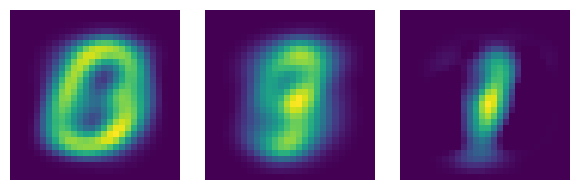

In [6]:
torch.manual_seed(0)

k = 1
num_samples = 3

z = Xc @ Vt[:k].T  
z_mean = z.mean(0)
z_std = z.std(0)
z_new = torch.randn(num_samples, k) * z_std + z_mean

print(z_std)

X_new = z_new @ Vt[:k] + mean 
X_new = torch.clamp(X_new, 0, 1)

fig, axes = plt.subplots(1,num_samples, figsize=(num_samples*2,2))
axes = [axes] if num_samples == 1 else axes
for i, ax in enumerate(axes):
  ax.imshow(X_new[i].view(28,28))
  ax.axis('off')
plt.tight_layout()
plt.show()

# COVARIANCE METHOD

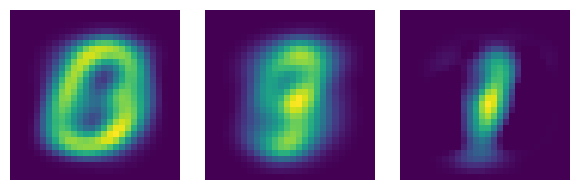

In [7]:
torch.manual_seed(0)

k = 1
num_samples = 3

Z = Xc @ Vt[:k].T
z_mean = Z.mean(dim=0)                     
Z_centered = Z - z_mean
cov = (Z_centered.T @ Z_centered) / (Z_centered.shape[0] - 1)   
dist = torch.distributions.MultivariateNormal(z_mean, covariance_matrix=cov)
z_new = dist.sample((num_samples,))          

X_new = z_new @ Vt[:k] + mean                  
X_new = torch.clamp(X_new, 0, 1)

fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 2, 2))
axes = [axes] if num_samples == 1 else axes
for i, ax in enumerate(axes):
    ax.imshow(X_new[i].view(28, 28).detach().numpy())
    ax.axis('off')
plt.tight_layout()
plt.show()


# Principle components probing

10


IndexError: index 10 is out of bounds for dimension 0 with size 10

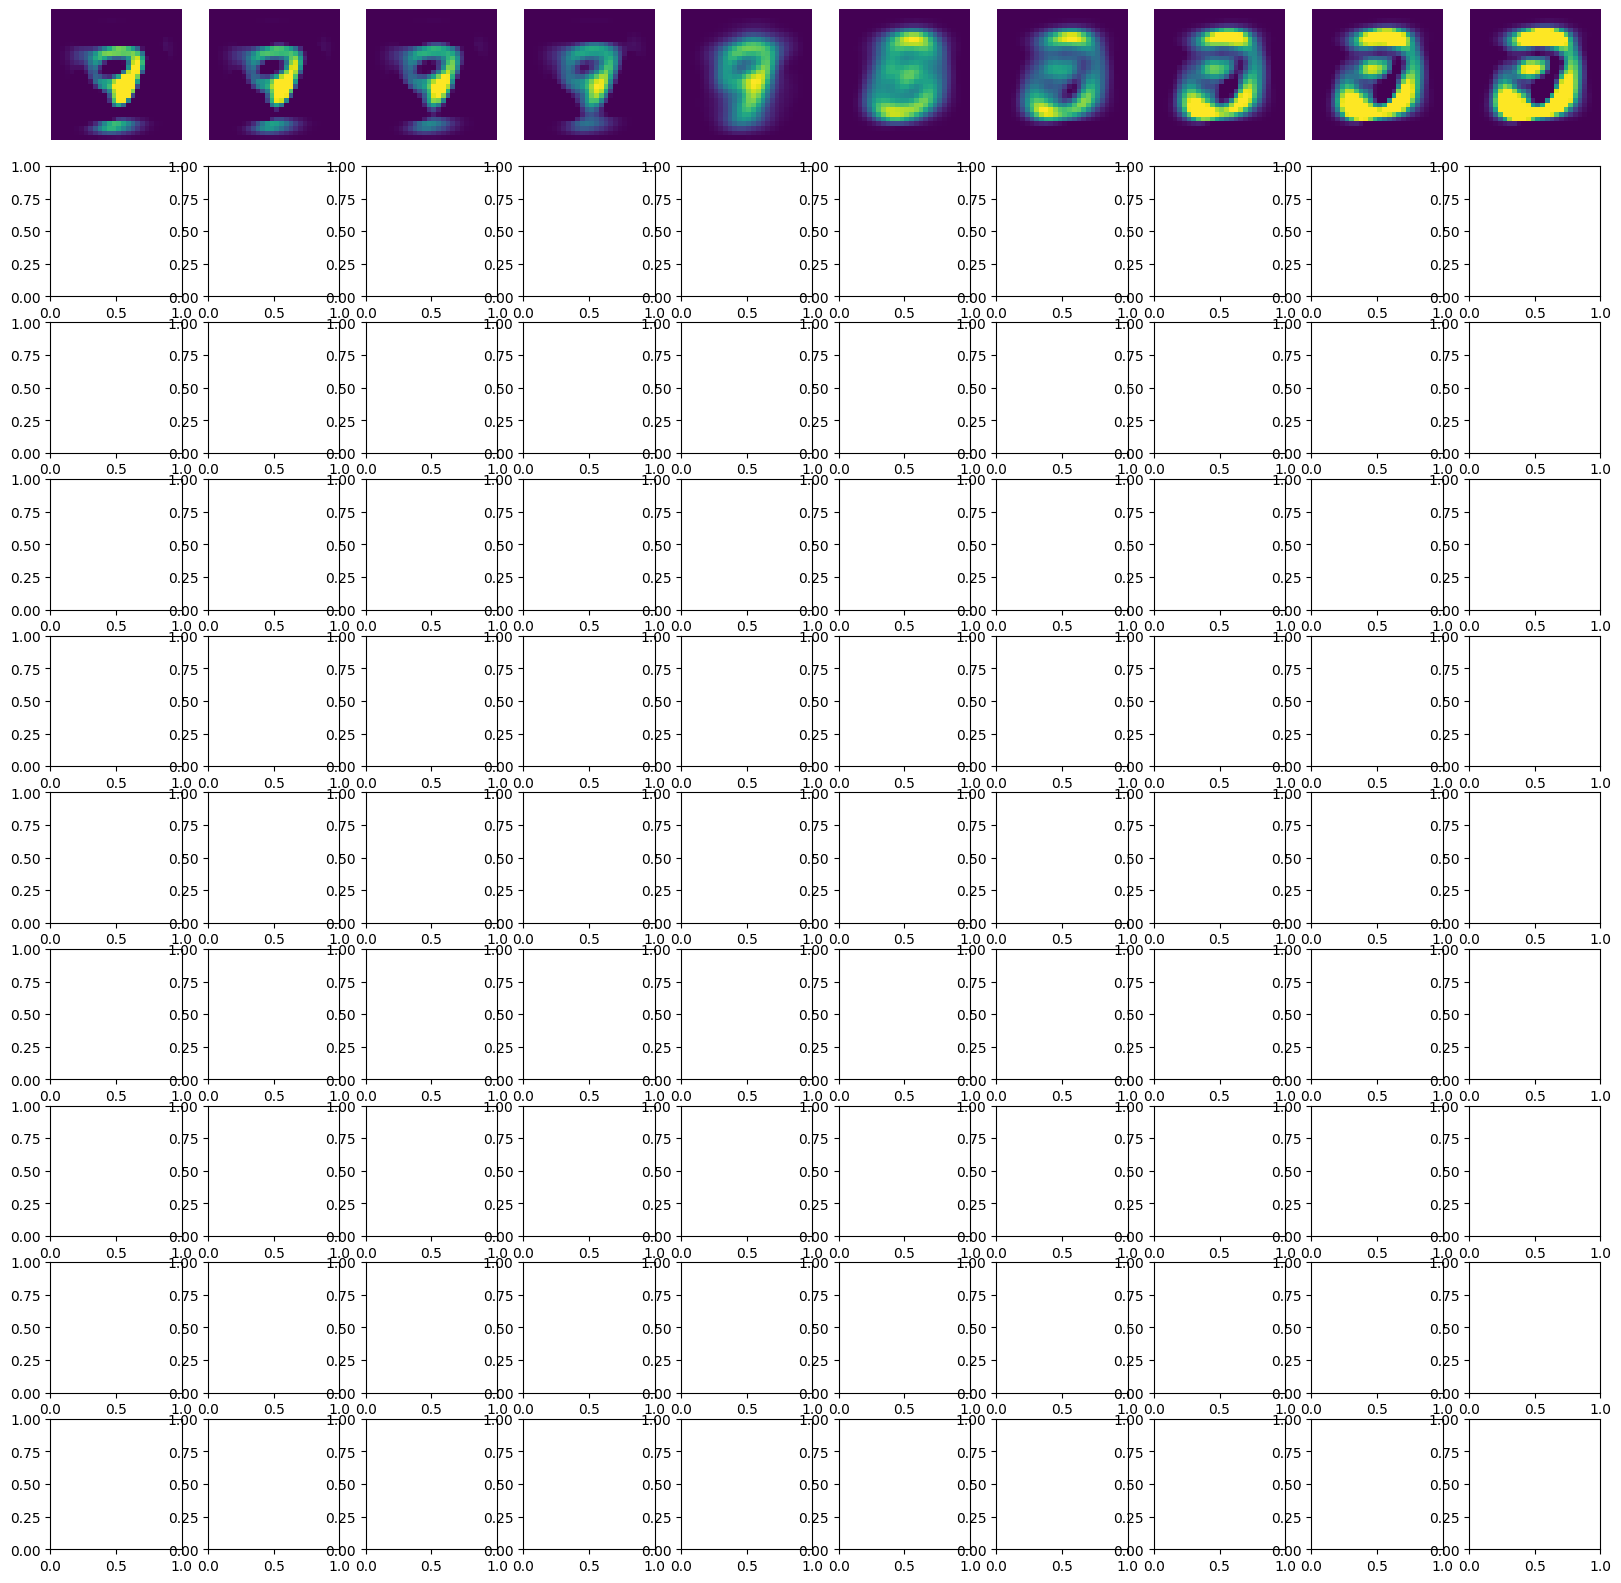

In [28]:
torch.manual_seed(0)

k = 2
num_samples = 10

Z = Xc @ Vt[:k].T
z_mean = Z.mean(dim=0)                     
Z_centered = Z - z_mean
cov = (Z_centered.T @ Z_centered) / (Z_centered.shape[0] - 1)   
dist = torch.distributions.MultivariateNormal(z_mean, covariance_matrix=cov)
z_new = dist.sample((num_samples,))          

ra_z = torch.linspace(-10,10,num_samples)
ra_z = torch.stack([ra_z, ra_z], dim=1)

X_new = ra_z @ Vt[:k] + mean                  
# X_new = z_new @ Vt[:k] + mean                  
X_new = torch.clamp(X_new, 0, 1)
print(X_new.shape[0])

fig, axes = plt.subplots(num_samples, num_samples, figsize=(num_samples*2, num_samples*2))
# axes = [axes] if num_samples == 1 else axes
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.imshow(X_new[i].view(28, 28))
    ax.axis('off')
plt.tight_layout()
plt.show()
